# Genomic LLMs Using PyTorch and Hugging Face Trainer API

## Hands-On Session

### Part 1 — Guided Demo
**Task:** Promoter Classification using DNABERT

### Part 2 — Self Hands-On
**Task:** Splice Site Classification using DNABERT

---

## Learning Outcomes

By the end of this session, participants will be able to:

- Fine-tune a pretrained genomic transformer
- Use Hugging Face Trainer API
- Configure TrainingArguments
- Save and reload models
- Perform inference on genomic sequences
- Evaluate genomic classification models
- Understand transfer learning for biological sequences

---

## Recommended Runtime

- Runtime Type: GPU
- GPU: T4 Recommended


In [1]:
# Installing required libraries
!pip -q install transformers datasets evaluate accelerate scikit-learn seaborn matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00


In [2]:
# Importing required libraries
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

from sklearn.metrics import accuracy_score, f1_score


# DNA as a Language

Large Language Models are fundamentally sequence learners.

In NLP:
- Tokens → words/subwords
- Sentences → sequences of tokens

In Genomics:
- Tokens → nucleotides or k-mers
- Sentences → DNA sequences

Genomic LLMs learn:
- sequence motifs
- regulatory patterns
- splice signals
- contextual biological relationships

In this workshop we use:
- DNABERT
- Hugging Face Trainer API
- Public genomic datasets
- PyTorch


# The Sequence Learning Paradigm Shift

Before executing our training loop, it is crucial to understand *why* we are using a computationally expensive Transformer for this task.

**Traditional Genomic ML:**
Historically, predicting genomic elements relied on Random Forests or SVMs. These require:
- Handcrafted features (e.g., GC-content percentages).
- Fixed k-mer frequency vectors (bag-of-words for DNA).
*Limitation:* They discard the spatial arrangement and long-range structural dependencies of the DNA string.

**The Transformer Advantage:**
Genomic LLMs treat DNA as a language. Through self-supervised pre-training, the attention mechanism learns:
- Contextual representations (a specific 6-mer means something different depending on what surrounds it).
- Long-range regulatory dependencies (e.g., an enhancer region thousands of base pairs away from a promoter).


# DNABERT

We use the pretrained model:

`zhihan1996/DNA_bert_6`

Key idea:
- DNA is converted into k-mers
- Transformer learns contextual biological representations
- Fine-tuning adapts the model for downstream tasks


In [3]:
MODEL_NAME = "zhihan1996/DNA_bert_6"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/1.45k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/40.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/28.7k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

# PART 1 — Guided Demo

## Task: Promoter Classification

This task predicts whether a DNA sequence is a potential promoter or a non-promoter

Dataset:
https://huggingface.co/datasets/darlednik/geneb-tasks

In [4]:
# Loading dataset
promoter_dataset = load_dataset("darlednik/geneb-tasks", "NT_promoter_all")
promoter_dataset

promoter_dataset["train"][0]

README.md:   0%|          | 0.00/24.3k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/100 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/100 [00:00<?, ?it/s]

tasks/InstaDeepAI_nucleotide_transformer(…):   0%|          | 0.00/16.2M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

{'text': 'ATAAAGCAACAGGAGGACACCGGCTCTCGCGTCATTAGGTCACACAATGTCTCAGTTTAAGGCGGGTGGGGTGGGCCAGACTCACAGCTGAGATAGAATTATTGCGAGATAACTCTGTTTAAGTAGCTAGGCTTGAAAATGGACGGTGAGTACCCTAGGACGTGCCCCAGGGCCAGTGGGATAAAGGTACACGCCGGCGGGGGCATGAGTCAGGGGTTTGCGAGCGAAAAAAGGAGCATTGGTTGCTACTGCGTTAGTGGGAACGTAGCTGGTCGCAGAGGGCACCTAATGCTGGCACCC',
 'label': 0}

## Tokenization Strategy

Transformers cannot directly process raw DNA.

We tokenize DNA sequences into representations understandable by the model.

Important concepts:
- sequence truncation
- padding
- attention masks
- contextual encoding

## Inside the Genomic Tokenizer

Unlike Natural Language Processing, which often uses Byte-Pair Encoding (BPE) to group common syllables, DNABERT relies on an **overlapping sliding window** of k-mers.

Why? Because biological signals don't have spaces or punctuation. Overlapping k-mers preserve the continuous spatial context of the sequence, ensuring no biological motif is accidentally split across a token boundary.


In [5]:
# Visualize the Sliding Window K-mer Extraction
def visualize_kmer_tokenization(sequence, k=6):
    print(f"Raw Sequence: {sequence}\n")
    print(f"Extracted {k}-mers (Sliding Window):")

    kmers = [sequence[i:i+k] for i in range(len(sequence) - k + 1)]
    for i, kmer in enumerate(kmers):
        # Indent to show the overlap visually
        print(f"{' ' * i}{kmer}")

# Testing on a short 15-base sequence
sample_dna = "ATGCGTAACGTTGAC"
visualize_kmer_tokenization(sample_dna)


Raw Sequence: ATGCGTAACGTTGAC

Extracted 6-mers (Sliding Window):
ATGCGT
 TGCGTA
  GCGTAA
   CGTAAC
    GTAACG
     TAACGT
      AACGTT
       ACGTTG
        CGTTGA
         GTTGAC


In [6]:
# Function to generate overlapping k-mers from a given sequence
def seq2kmer(seq, k=6):
    return " ".join([seq[i:i+k] for i in range(len(seq) - k + 1)])

# Function to tokenize a given sequence
def tokenize_promoter(example):
    # Convert a batch of raw strings to spaced k-mers
    kmer_texts = [seq2kmer(seq) for seq in example["text"]]

    return tokenizer(
        kmer_texts,
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_promoter = promoter_dataset.map(tokenize_promoter, batched=True)


Map:   0%|          | 0/53276 [00:00<?, ? examples/s]

Map:   0%|          | 0/5920 [00:00<?, ? examples/s]

In [7]:
# Train/Test dataset with 80-20 split
train_promoter = tokenized_promoter["train"].shuffle(seed=42).select(range(20000))
test_promoter = tokenized_promoter["test"].shuffle(seed=42).select(range(2000))
promoter_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)


pytorch_model.bin:   0%|          | 0.00/359M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/359M [00:00<?, ?B/s]

[transformers] BertForSequenceClassification LOAD REPORT from: zhihan1996/DNA_bert_6
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Evaluation Metrics

We use:
- Accuracy
- Weighted F1-score

F1-score is especially important in genomics due to:
- imbalance
- asymmetric biological consequences
- sensitivity requirements


In [8]:
# Function to compute evaluation metrics
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    f1 = f1_score(labels, predictions, average="weighted")

    return {
        "accuracy": accuracy,
        "f1": f1
    }


## TrainingArguments Deep Dive

Key parameters:
- learning rate
- evaluation strategy
- checkpoint saving
- batch size
- weight decay
- logging
- best model loading


In [9]:
promoter_training_args = TrainingArguments(
    output_dir="./promoter_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_dir="./promoter_logs",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="f1"
)

promoter_trainer = Trainer(
    model=promoter_model,
    args=promoter_training_args,
    train_dataset=train_promoter,
    eval_dataset=test_promoter,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


## Fine-Tuning the Model

Observe:
- training loss
- evaluation metrics
- checkpoint saving
- runtime behavior

In [ ]:
promoter_trainer.train()

promoter_results = promoter_trainer.evaluate()
promoter_results

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.344752,0.328619,0.866000,0.865911


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.344752,0.328619,1,0.866000,0.865911


{'eval_loss': 0.3286193907260895,
 'eval_accuracy': 0.866,
 'eval_f1': 0.8659114803322991}

## Saving and Reloading the Model

Critical for:
- reproducibility
- downstream inference
- sharing checkpoints


In [ ]:
# Saving the fine-tuned model
promoter_trainer.save_model("./promoter_model")
tokenizer.save_pretrained("./promoter_model")

# Loading the saved model back
loaded_promoter_model = AutoModelForSequenceClassification.from_pretrained(
    "./promoter_model"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

## Inference
We now perform prediction on unseen sequences.


In [ ]:
# Method to perform prediction on a sequence using the fine-tuned model
def promoter_predict(sequence):

    inputs = tokenizer(
        sequence,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = loaded_promoter_model(**inputs)

    prediction = torch.argmax(outputs.logits, dim=1).item()
    return prediction


In [ ]:
# Run prediction
sample_sequence = promoter_dataset["test"][0]["text"]

prediction = promoter_predict(sample_sequence)

print("Prediction:", prediction)


Prediction: 1


## In Silico Saturated Mutagenesis

In the wet lab, researchers perform knockout experiments or saturated mutagenesis to determine which specific nucleotides are essential for a biological function.

We can recreate this digitally. By systematically mutating every position in a sequence window and plotting the drop in the model's confidence, we can force the model to reveal the sequence motifs it considers most critical.


Running in silico mutagenesis...


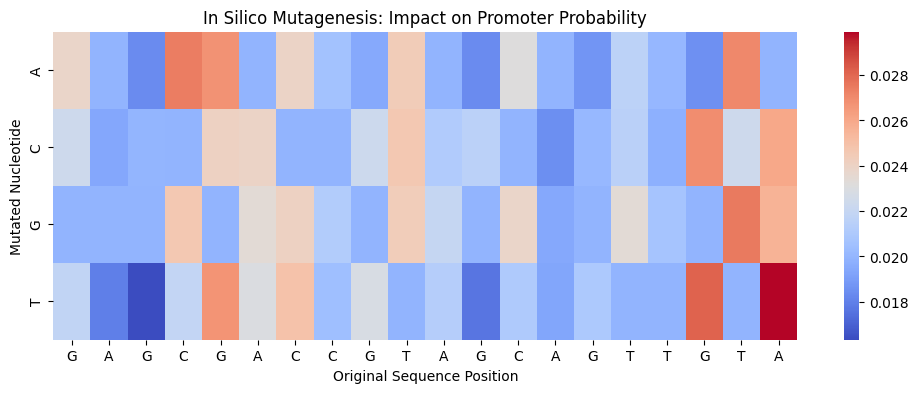

Look for distinct 'cool' (blue) vertical bands. These represent highly sensitive positions where ANY mutation destroys the model's confidence—likely a critical biological motif!


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn.functional as F

def get_promoter_probability(seq):
    # Convert the sequence before tokenizing
    kmer_seq = seq2kmer(seq)

    inputs = tokenizer(kmer_seq, return_tensors="pt", truncation=True, max_length=128)
    with torch.no_grad():
        # Make sure inputs are moved to the same device as your model if using GPU
        device = loaded_promoter_model.device
        inputs = {k: v.to(device) for k, v in inputs.items()}
        logits = loaded_promoter_model(**inputs).logits

    probs = F.softmax(logits, dim=-1)
    return probs[0][1].item()

original_sequence = promoter_dataset["test"][0]["text"]
window_start, window_end = 20, 40
target_window = original_sequence[window_start:window_end]

nucleotides = ['A', 'C', 'G', 'T']
mutation_results = np.zeros((4, len(target_window)))

print("Running in silico mutagenesis...")
for pos in range(len(target_window)):
    for n_idx, nuc in enumerate(nucleotides):
        mutated_seq = original_sequence[:window_start + pos] + nuc + original_sequence[window_start + pos + 1:]
        mutation_results[n_idx, pos] = get_promoter_probability(mutated_seq)

plt.figure(figsize=(12, 4))
ax = sns.heatmap(mutation_results, annot=False, cmap="coolwarm",
                 xticklabels=list(target_window), yticklabels=nucleotides)
plt.title("In Silico Mutagenesis: Impact on Promoter Probability")
plt.xlabel("Original Sequence Position")
plt.ylabel("Mutated Nucleotide")
plt.show()

print("Look for distinct 'cool' (blue) vertical bands. These represent highly sensitive positions where ANY mutation destroys the model's confidence—likely a critical biological motif!")


# PART 2 — Full Hands-On Self Exercise

## Task: Splice Site Classification

Dataset:
https://huggingface.co/datasets/InstaDeepAI/nucleotide_transformer_downstream_tasks (Subset: splice_sites_acceptors)

---

## Objective

Participants to now independently:
- preprocess a new dataset
- fine-tune DNABERT
- configure Trainer API
- evaluate performance
- perform inference

This section intentionally leaves implementation gaps for exploration.


In [ ]:
full_dataset = load_dataset("InstaDeepAI/nucleotide_transformer_downstream_tasks", "default")

print("Filtering master dataset for Splice Sites...")
splice_dataset = full_dataset.filter(lambda example: example["task"] == "splice_sites_acceptors")

splice_dataset

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

H4ac/train.parquet:   0%|          | 0.00/7.94M [00:00<?, ?B/s]

promoter_tata/train.parquet:   0%|          | 0.00/867k [00:00<?, ?B/s]

H3K4me3/train.parquet:   0%|          | 0.00/8.58M [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/48797 [00:00<?, ? examples/s]

Filtering master dataset for Splice Sites...


Filter:   0%|          | 0/461850 [00:00<?, ? examples/s]

Filter:   0%|          | 0/48797 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sequence', 'name', 'label', 'task'],
        num_rows: 19961
    })
    test: Dataset({
        features: ['sequence', 'name', 'label', 'task'],
        num_rows: 2218
    })
})

## Exercise 1

Inspect:
- dataset structure
- labels
- sequence length distribution

Tasks:
1. Explore sample records
2. Identify label names
3. Understand sequence structure


In [ ]:
# YOUR CODE HERE


## Exercise 2

Create a tokenization function for splice site sequences.

Recommended parameters:
- truncation=True
- padding="max_length"
- max_length=128


In [ ]:
# YOUR CODE HERE


## Exercise 3

Tokenize the dataset and create:
- training subset
- evaluation subset

Recommended sizes:
- train: 1000
- test: 200


In [ ]:
# YOUR CODE HERE


## Exercise 4

Load DNABERT for sequence classification.

Important:
- correct number of labels
- classification head initialization


In [ ]:
# YOUR CODE HERE


## Exercise 5

Define TrainingArguments.

Suggested parameters:
- epochs = 1
- batch size = 8
- learning rate = 2e-5
- evaluation strategy = epoch


In [ ]:
# YOUR CODE HERE


## Exercise 6

Create the Trainer object.

Include:
- compute_metrics
- EarlyStoppingCallback


In [ ]:
# YOUR CODE HERE


## Exercise 7: The Challenge

**The Problem:** Splice site datasets represent the real-world biological environment: they are massively imbalanced. True splice sites are incredibly rare compared to random genomic background noise.

If you use standard `accuracy` here, a model that simply predicts "Non-Splice" 100% of the time will achieve ~99% accuracy, rendering it useless.

**Your Challenge:** Do not use basic accuracy. Modify your `compute_metrics` function to calculate the **PR-AUC (Precision-Recall Area Under Curve)** using `scikit-learn`.

*Hint:* You will need `average_precision_score` from `sklearn.metrics`. You must pass the model's raw probabilities (logits), not just the hardened `argmax` predictions!


In [ ]:
from sklearn.metrics import average_precision_score
import torch.nn.functional as F

def compute_imbalanced_metrics(eval_pred):
    # YOUR CODE HERE
    # 1. Extract logits and labels
    # 2. Convert logits to probabilities using softmax
    # 3. Calculate PR-AUC using average_precision_score

    pass

# Update your Trainer arguments to use this new metric!


## Exercise 8

Perform inference on a custom DNA sequence.

Try:
- modifying nucleotides
- introducing mutations
- comparing predictions


In [ ]:
# YOUR CODE HERE


# FAQs and Points to Ponder

- Why do genomic transformers outperform CNNs in many sequence tasks?
- What are the limitations of k-mer tokenization?
- How does context length influence biological learning?
- What happens with very long genomic sequences?
- Why is transfer learning valuable in genomics?
- How can attention maps be biologically interpreted?




---


# End of Workshop

## Key Takeaways

- DNA can be treated as a language
- Transformers are powerful biological sequence learners
- Hugging Face Trainer API simplifies experimentation
- Transfer learning enables efficient genomic modeling
- Genomic LLMs are increasingly important in computational biology


# Visualizing Specialized Attention Heads

Transformers don't just look at the sequence generally. Different attention heads in different layers specialize in specific tasks. In genomic models, early layers often look at local syntax (e.g., repeating GC loops), while deeper layers look for functional motifs.

Let's isolate a single attention head in the final layer to see exactly what biological tokens it is focusing on.


In [ ]:
from transformers import AutoModel
import matplotlib.pyplot as plt

# Load base model to expose attentions
attention_model = AutoModel.from_pretrained(MODEL_NAME, output_attentions=True)
sample_seq = promoter_dataset["test"][0]["sequence"][:40]

inputs = tokenizer(sample_seq, return_tensors="pt", truncation=True, max_length=64)
outputs = attention_model(**inputs)

# Extract tokens to use as labels
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

# ISOLATE: Last layer (-1), Batch (0), Specific Head (let's look at head 4)
layer_idx = -1
head_idx = 4
attention_matrix = outputs.attentions[layer_idx][0, head_idx].detach().numpy()

plt.figure(figsize=(10,8))
plt.imshow(attention_matrix, cmap='viridis')
plt.title(f"Attention Map (Layer {layer_idx}, Head {head_idx})")
plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.yticks(range(len(tokens)), tokens)
plt.colorbar(label="Attention Weight")
plt.tight_layout()
plt.show()
